In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

%matplotlib inline

In [ ]:
def pos_to_char(pos):
    return chr(pos + 65).lower()

In [ ]:
sns.set_palette("tab10")

# Fixation times
### (1) Viability selection (constant population size), (2) Fecundity selection (constant population size)


In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "adapted" not in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [ ]:
sns.set(font_scale = 1.3, style="whitegrid")

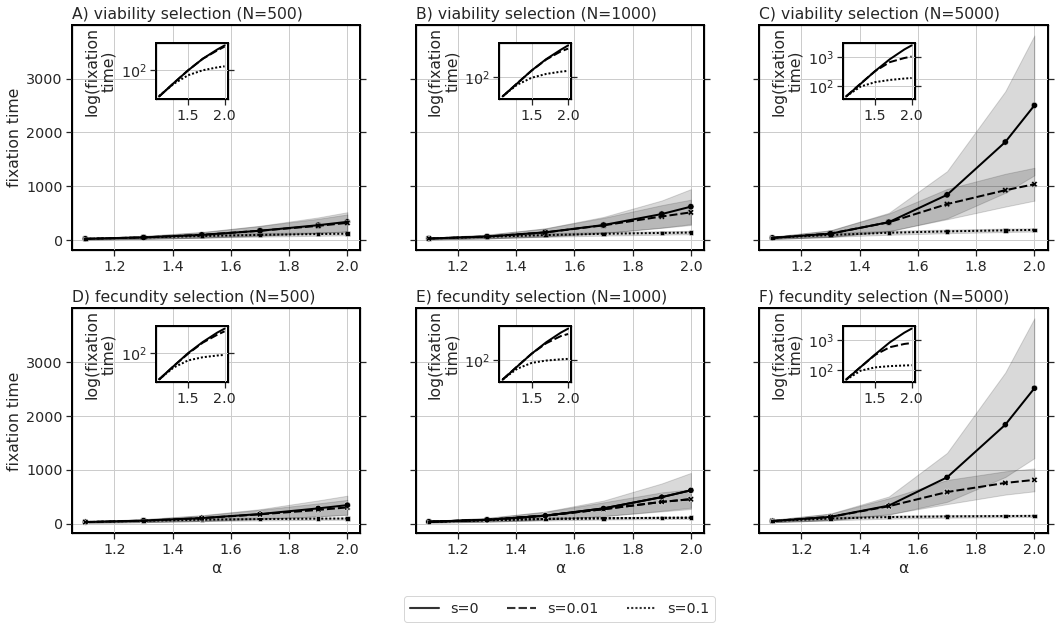

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_constant.pdf", dpi=500)

## (3) Difference between viability and fecundity selection (constant population size)

In [ ]:
files = os.listdir("./simulations/")
files = ["./simulations/" + file for file in files]
# filter the timess
df_time = [pd.read_csv(file) for file in files if "time" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "constant"]

In [ ]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]
population_sizes = [500, 1000, 5000]

difference_frame = []

for population_size in population_sizes:

    for selection_coefficient in selection_coefficients:

        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha, diff_std)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

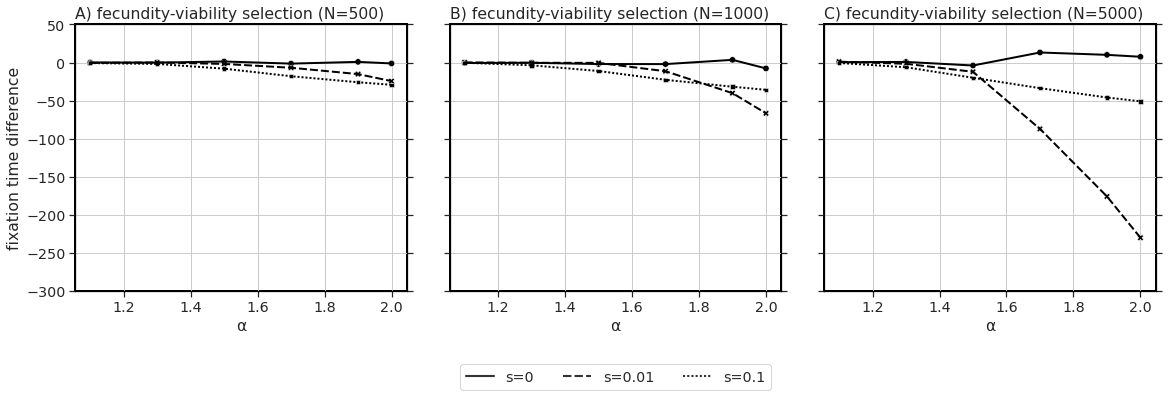

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_constant.pdf", dpi=500)


## (4) Viability selection (sinus population size), (5) Fecundity selection (sinus population size)

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [ ]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

[578, 1156, 5777]

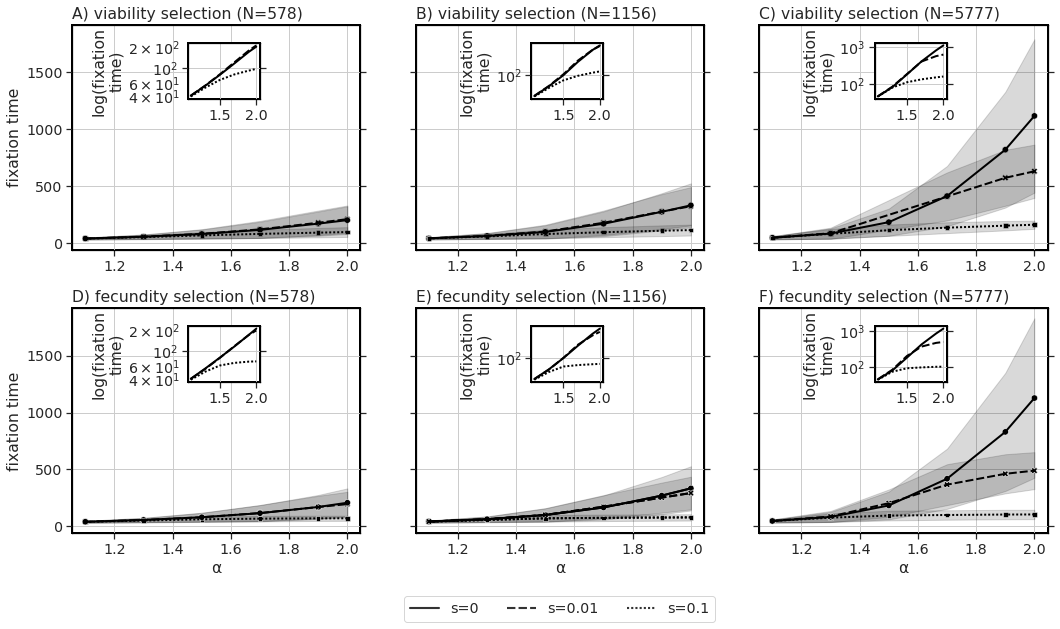

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.40, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.40, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_sinus_selection_constant.pdf", dpi=500)

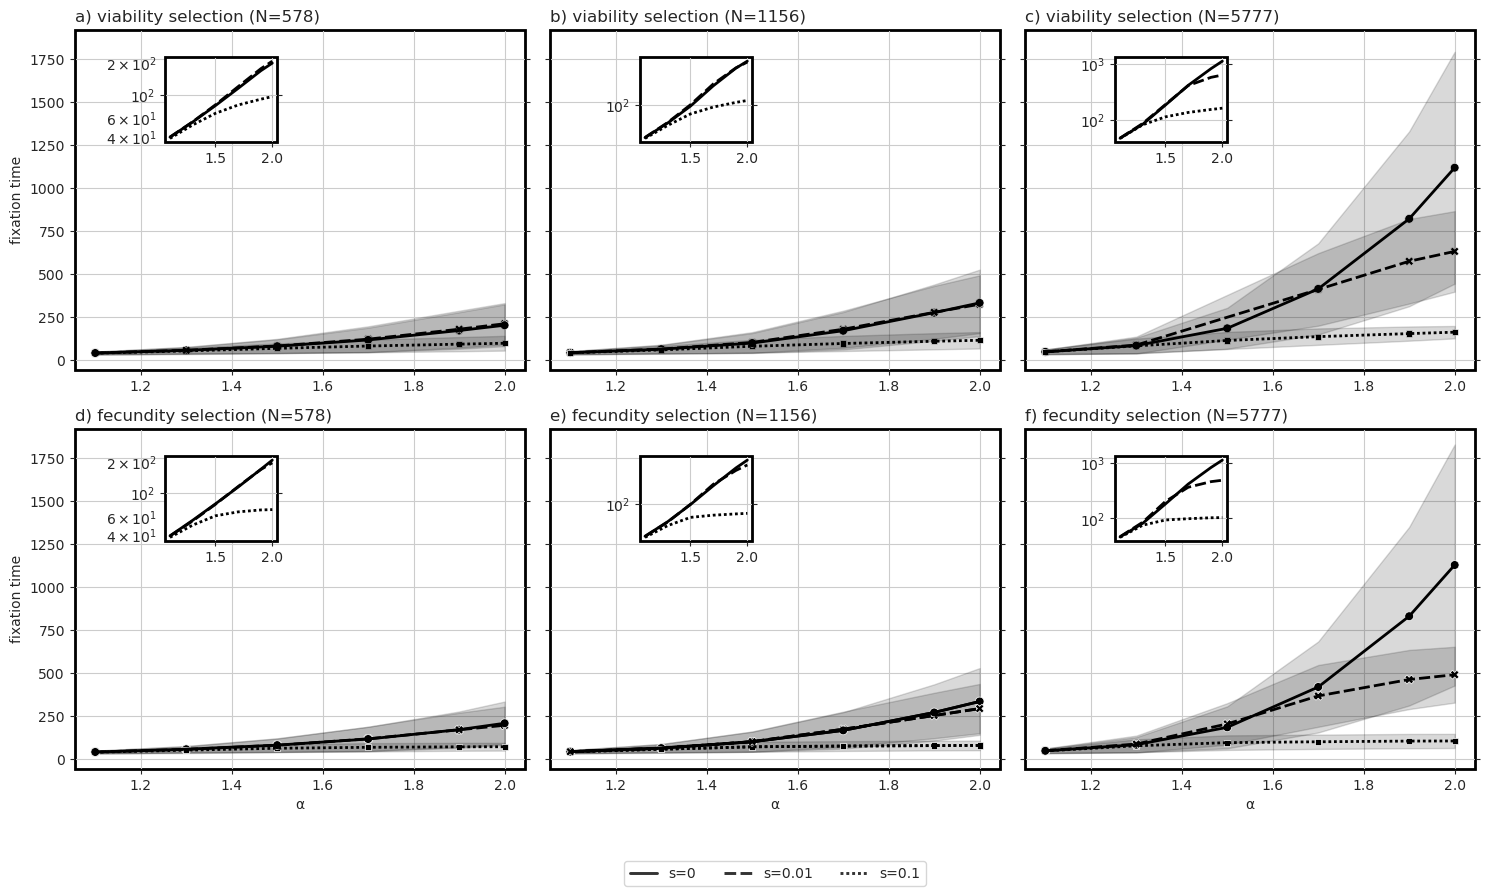

In [ ]:
# new

sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.20, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.20, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_sinus_selection_constant.pdf", dpi=500)

## (6) Viability selection (shifted sinus population size), (7) Fecundity selection (shifted sinus population size)

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [ ]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

[578, 1156, 5777]

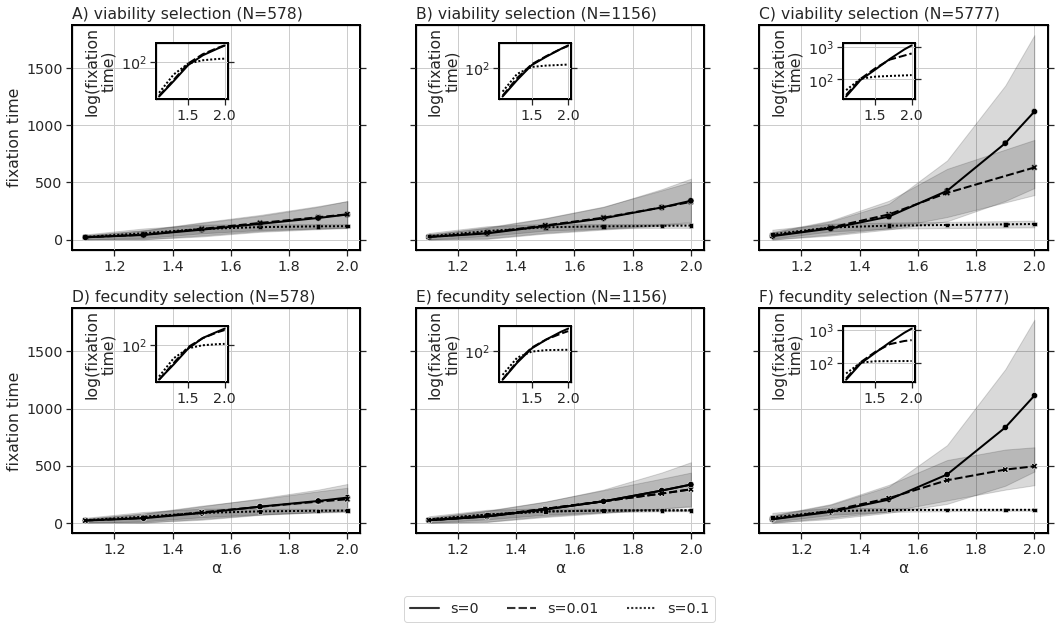

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)

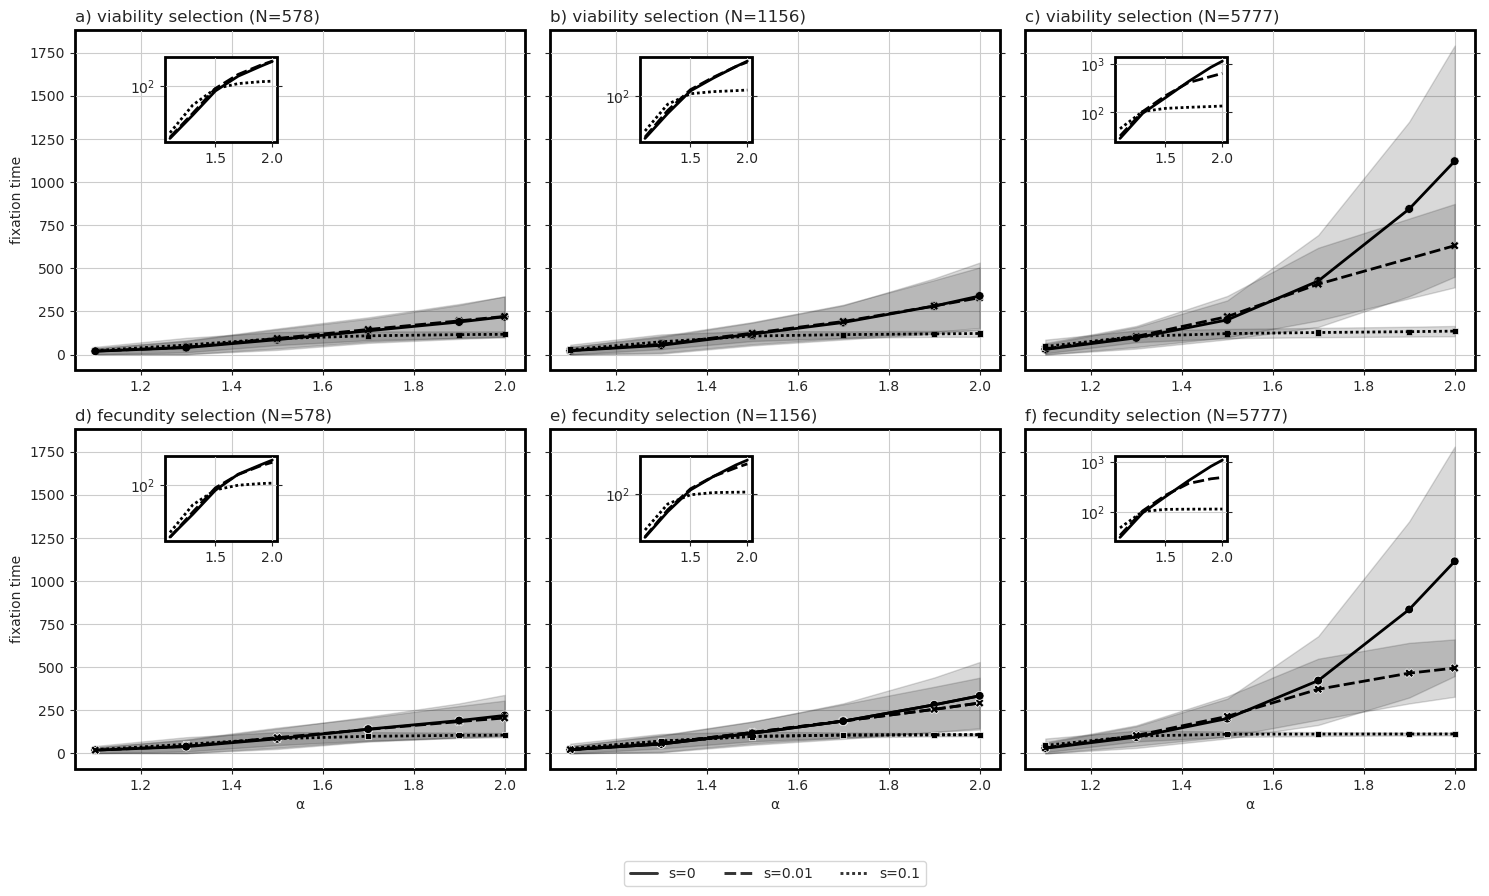

In [ ]:
# new

sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)

## (8) Difference between viability and fecundity selection (sinus population size)

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

5777 0.01 1.5


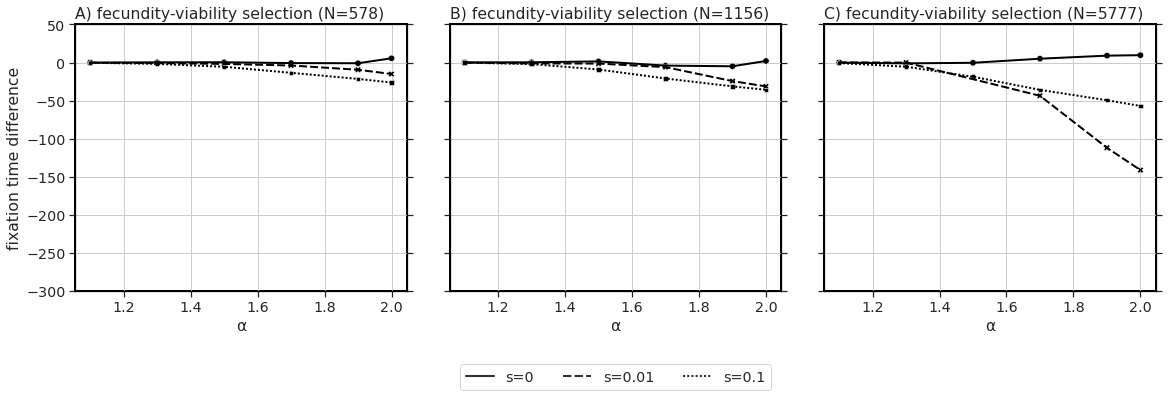

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_sinus_selection_constant.pdf", dpi=500)


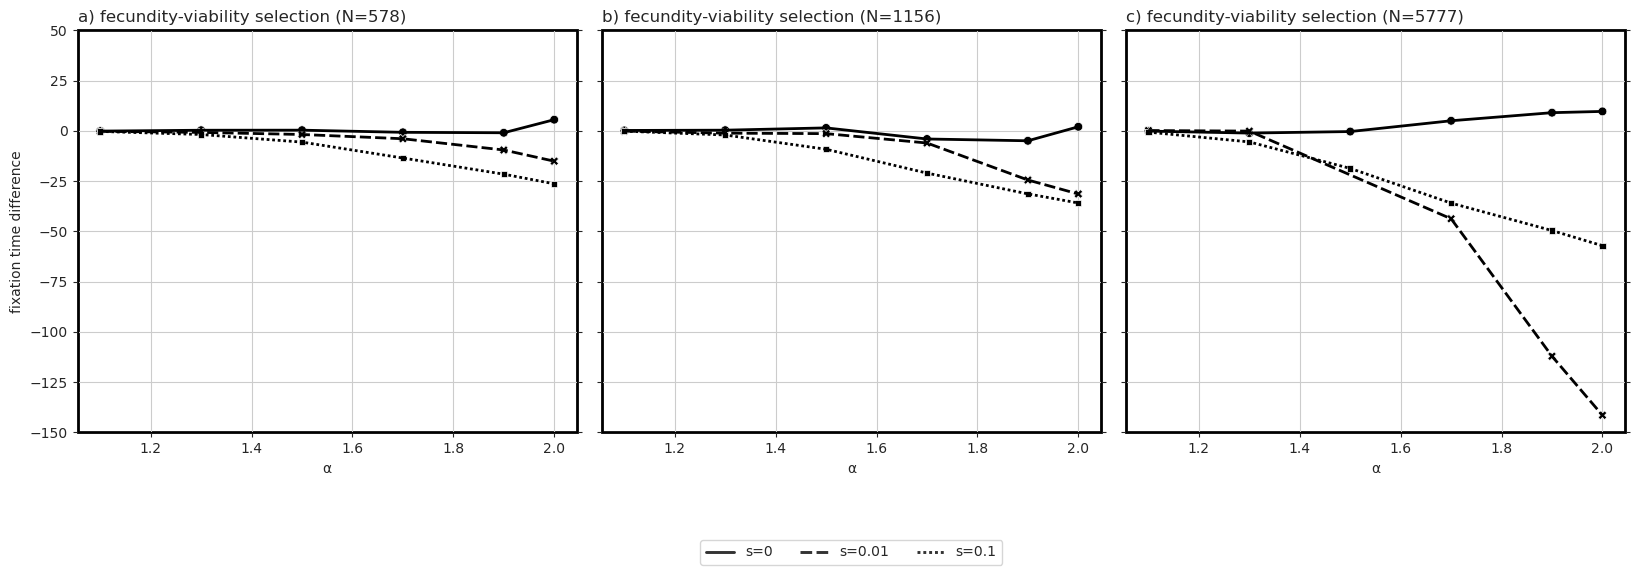

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth(2) 
    ax.set_ylim(-150, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_sinus_selection_constant.pdf", dpi=500)


## (9) Difference between viability and fecundity selection (sinus shifted population size)

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]
selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

5777 0.01 1.9


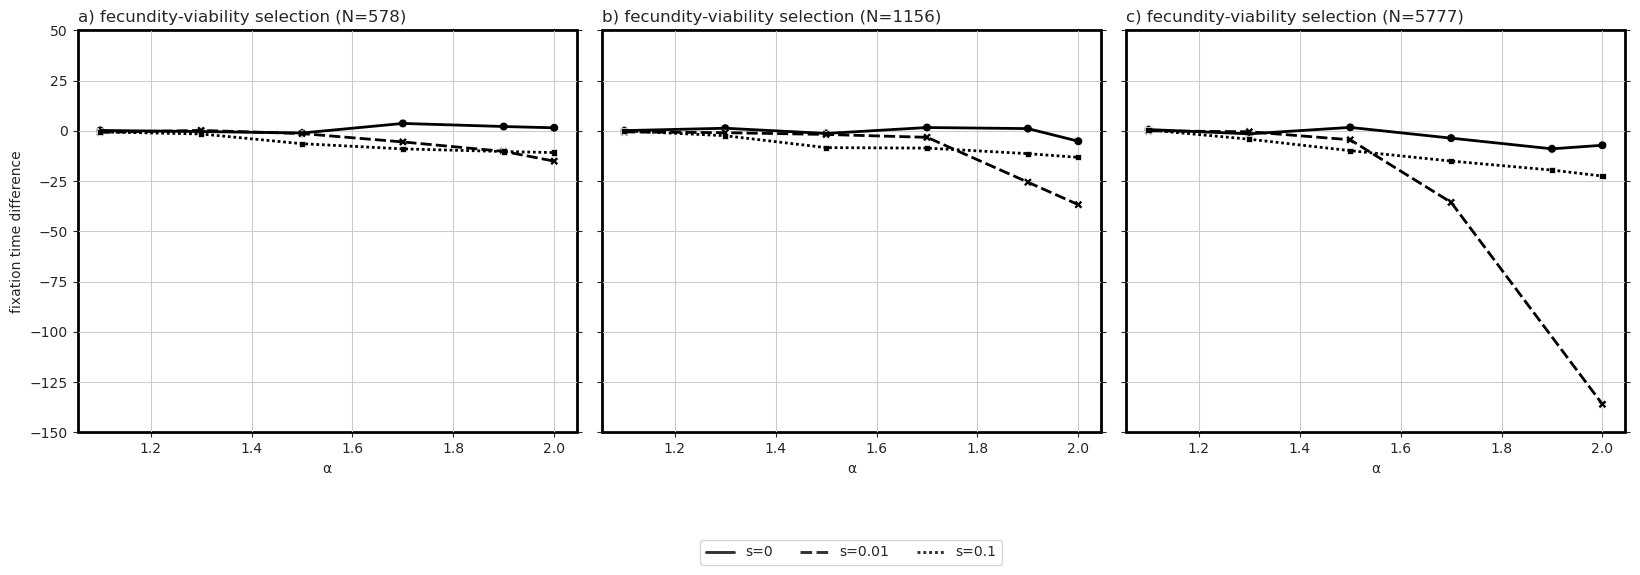

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth(2) 
    ax.set_ylim(-150, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


## (10) Viability selection (sinus selection), (11) Fecundity selection (sinus selection)

In [ ]:
files = os.listdir("./simulations/")
files = ["./simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

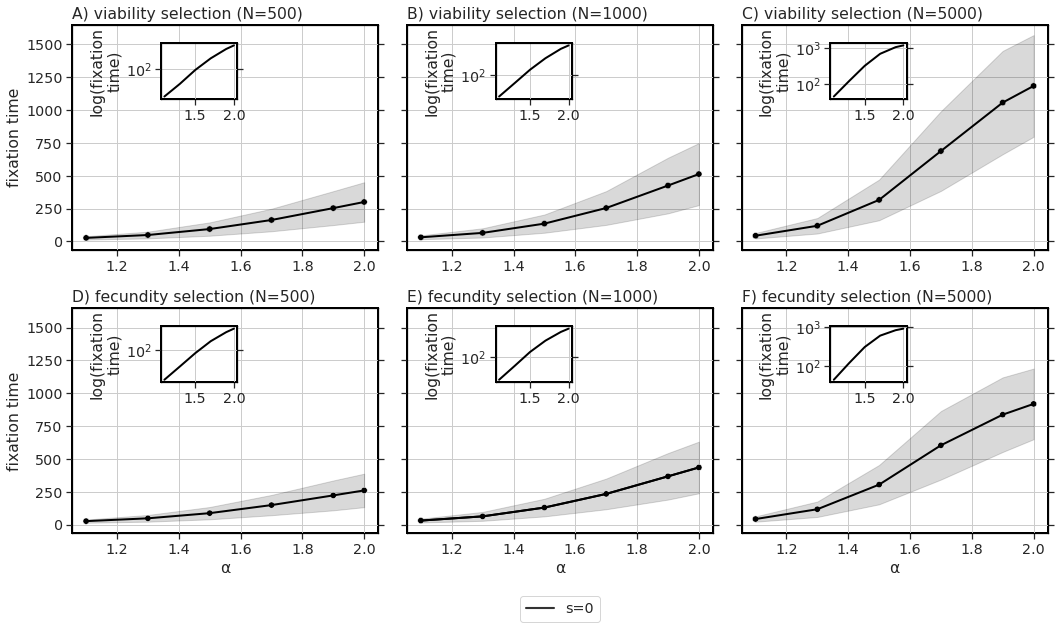

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_sinus.pdf", dpi=500)

## (12) Viability selection (shifted sinus selection), (13) Fecundity selection (shifted sinus selection)

In [ ]:
files = os.listdir("./simulations/")
files = ["./simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

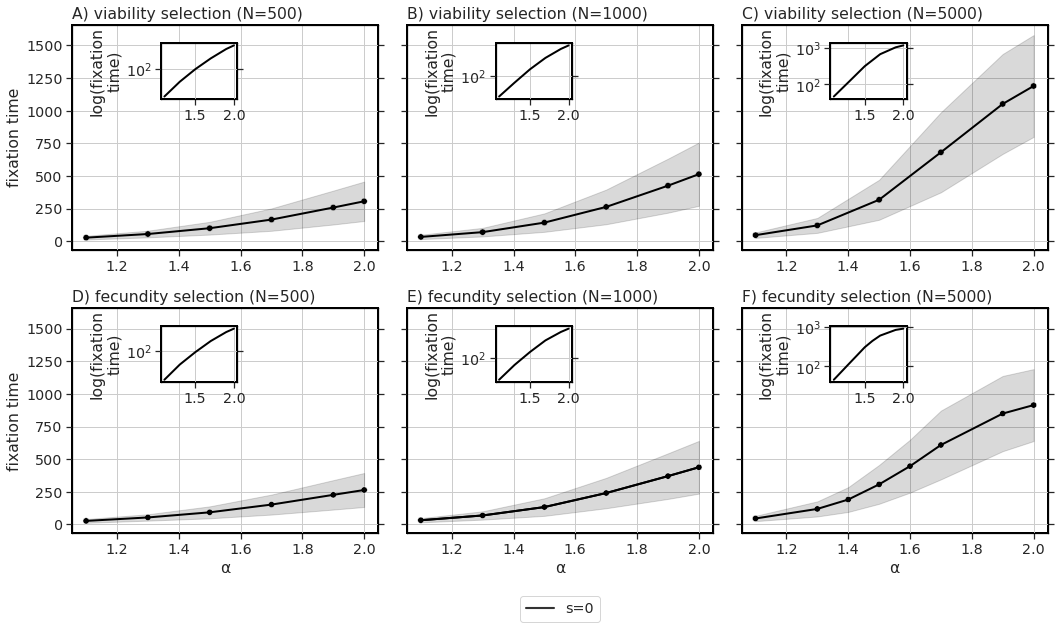

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)

## (14) Difference between viability and fecundity selection (sinus selection)

In [ ]:
files = os.listdir("./simulations/")
files = ["./simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [ ]:
difference_frame = []
for population_size in [500, 1000, 5000]:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                #print(alpha, diff, population_size, selection_coefficient, [fc.standard_deviation, vc.standard_deviation])
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                
                #print(diff, diff_std)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except Exception as e:
                print(population_size, selection_coefficient, alpha, e)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

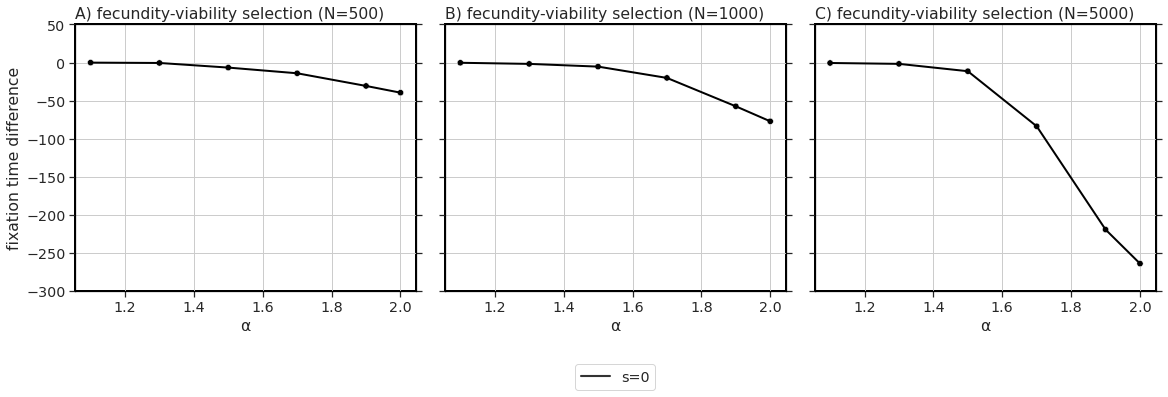

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_sinus.pdf", dpi=500)


## (15) Difference between viability and fecundity selection (shifted sinus selection)

In [ ]:
files = os.listdir("./simulations/")
files = ["./simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [ ]:


difference_frame = []
for population_size in [500, 1000, 5000]:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

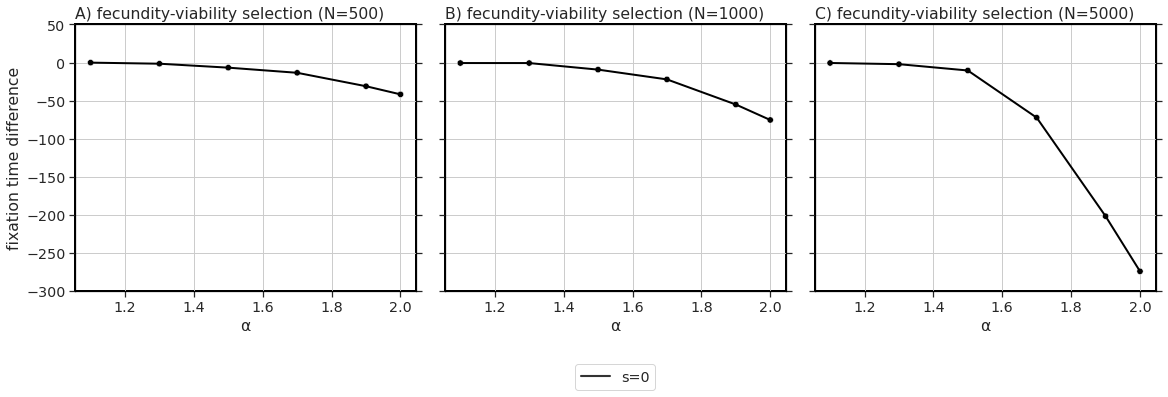

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)


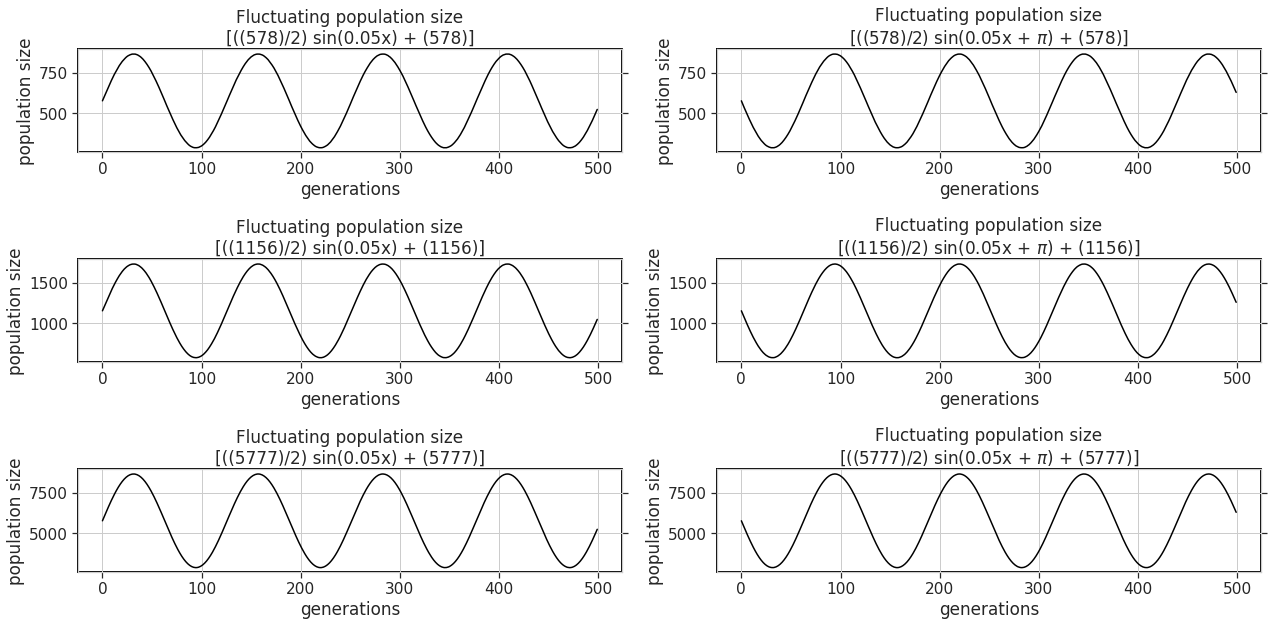

In [ ]:
sns.set(font_scale = 1.4, style="whitegrid")
fig, axs = plt.subplots(3,2, figsize=(18, 9), sharey=False)

N = 500
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 578
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
ax = axs[0][0]
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((578)/2) sin(0.05x) + (578)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')


ax = axs[1][0]
N = 1000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 1156
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((1156)/2) sin(0.05x) + (1156)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')



ax = axs[2][0]
N = 5000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 5777
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((5777)/2) sin(0.05x) + (5777)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')





N = 500
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 578
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
ax = axs[0][1]
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((578)/2) sin(0.05x + $\pi$) + (578)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')


ax = axs[1][1]
N = 1000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 1156
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((1156)/2) sin(0.05x + $\pi$) + (1156)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')



ax = axs[2][1]
N = 5000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 5777
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((5777)/2) sin(0.05x + $\pi$) + (5777)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')

plt.tight_layout()
plt.savefig("./figures/fluctuating_population_size.pdf", dpi=500)

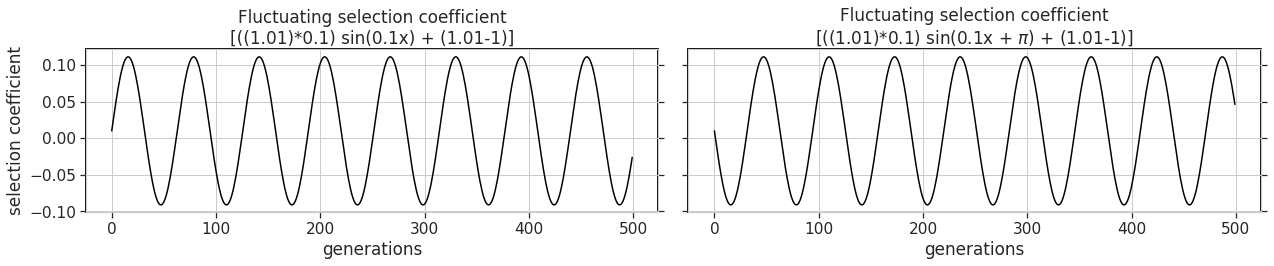

In [ ]:

sns.set(font_scale = 1.4, style="whitegrid")
fig, axs = plt.subplots(1,2, figsize=(18, 4), sharey=True)

ax = axs[0]
N = 1
period = 0.1
start ,stop, step = 0, 500, 1
x = np.arange(start, stop, step)  
y = (1.01) * 0.1 * np.sin(period * x) + (1.01-1)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating selection coefficient\n[((1.01)*0.1) sin(0.1x) + (1.01-1)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='selection coefficient')

ax = axs[1]
N = 1
period = 0.1
start ,stop, step = 0, 500, 1
x = np.arange(start, stop, step)  
y = (1.01) * 0.1 * np.sin(period * x + np.pi) + (1.01-1)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating selection coefficient\n[((1.01)*0.1) sin(0.1x + $\pi$) + (1.01-1)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='selection coefficient')


plt.tight_layout()
plt.savefig("./figures/fluctuating_selection_coefficient.pdf", dpi=500)



In [ ]:
from copy import deepcopy

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "adapted" not in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

fecundity_constant_df["adapted_alpha"] = False
fecundity_constant_df_non_adapted_alpha = deepcopy(fecundity_constant_df)

In [ ]:
files = os.listdir("../simulations/")
files = ["../simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "adapted" in file and "time" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

fecundity_constant_df_adapted_alpha = deepcopy(fecundity_constant_df)


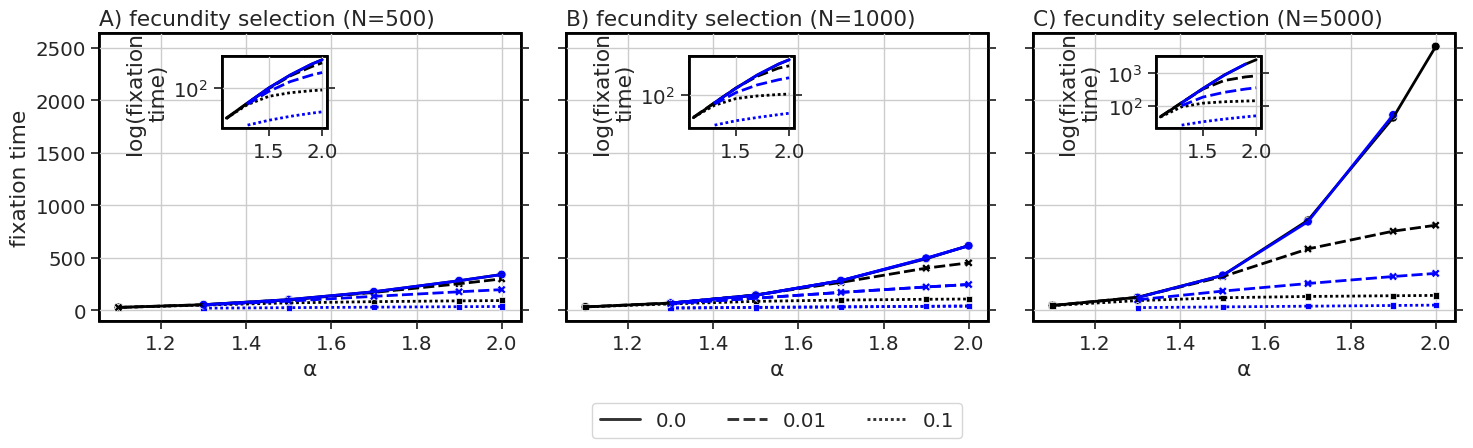

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)



for i, population_size in enumerate([500, 1000, 5000]):
    
    
    
    
    fecundity_constant_df = deepcopy(fecundity_constant_df_non_adapted_alpha)
    
    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "black"
    color = "black"
    linewidth = 2

    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    #if i == 1:
    #    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    #ins.set_yscale("log")
    #ins.set(xlabel='', ylabel='log(fixation\ntime)')
    #ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    #ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    
    
    
    
    
    
    
    
    fecundity_constant_df = deepcopy(fecundity_constant_df_adapted_alpha)
    
    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "blue"
    color = "blue"
    linewidth = 2

    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    #ins = axs[i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol) #labels=["s=0","s=0.01","s=0.1"]
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_constant_diff-model.pdf", dpi=500)